In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
A = np.array([[0,1,0,0],
              [0,0,1,0],
              [0,0,0,0],
              [0,0,0,0]])

Text(0.5, 1.0, 'GT')

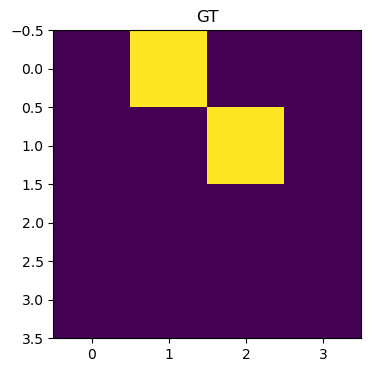

In [4]:
plt.figure(figsize=(4,4))
plt.imshow(A!=0)
plt.title('GT')

In [5]:
df = pd.read_csv(r'./data/demo_dataset.csv', header=0)
X_ = df.values
X = X_.T
print(X.shape)

(4, 4000)


## Analysis

In [6]:
N_PASTS, n_lags, n_perm = np.arange(2, 5, 1), 2, 1000
alpha, beta = 0.01, 0.001

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


2 pasts


C:\Users\sadiq\Documents\GC-extension\examples\..\src\d_CSL.py:32: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  corr_1 = np.corrcoef(x, y)[1, 0]
INFO:src.d_CSL:Step 1/48 (2.08% complete)
INFO:src.d_CSL:Step 1/48 (2.08% complete)
INFO:src.d_CSL:Step 2/48 (4.17% complete)
INFO:src.d_CSL:Step 3/48 (6.25% complete)
INFO:src.d_CSL:Step 4/48 (8.33% complete)
INFO:src.d_CSL:Step 5/48 (10.42% complete)
INFO:src.d_CSL:Step 6/48 (12.50% complete)
INFO:src.d_CSL:Step 7/48 (14.58% complete)
INFO:src.d_CSL:Step 8/48 (16.67% complete)
INFO:src.d_CSL:Step 9/48 (18.75% complete)
INFO:src.d_CSL:Step 10/48 (20.83% complete)
INFO:src.d_CSL:Step 11/48 (22.92% complete)
INFO:src.d_CSL:Step 2/48 (4.17% complete)
INFO:src.d_CSL:Step 12/48 (25.00% complete)
INFO:src.d_CSL:Step 13/48 (27.08% complete)
INFO:src.d_CSL:Step 14/48 (29.17% complete)
INFO:src.d_CSL:Step 15/48 (31.25% complete)
INFO:src.d_CSL:Step 16/48 (33.33% complete)
INFO:src.d_CSL:Step 17/48 (

3 pasts


INFO:src.d_CSL:Step 5/64 (7.81% complete)
INFO:src.d_CSL:Step 6/64 (9.38% complete)
INFO:src.d_CSL:Step 7/64 (10.94% complete)
INFO:src.d_CSL:Step 8/64 (12.50% complete)
INFO:src.d_CSL:Step 9/64 (14.06% complete)
INFO:src.d_CSL:Step 10/64 (15.62% complete)
INFO:src.d_CSL:Step 1/64 (1.56% complete)
INFO:src.d_CSL:Step 11/64 (17.19% complete)
INFO:src.d_CSL:Step 12/64 (18.75% complete)
INFO:src.d_CSL:Step 13/64 (20.31% complete)
INFO:src.d_CSL:Step 14/64 (21.88% complete)
INFO:src.d_CSL:Step 15/64 (23.44% complete)
INFO:src.d_CSL:Step 16/64 (25.00% complete)
INFO:src.d_CSL:Step 17/64 (26.56% complete)
INFO:src.d_CSL:Step 18/64 (28.12% complete)
INFO:src.d_CSL:Step 19/64 (29.69% complete)
INFO:src.d_CSL:Step 20/64 (31.25% complete)
INFO:src.d_CSL:Step 21/64 (32.81% complete)
INFO:src.d_CSL:Step 22/64 (34.38% complete)
INFO:src.d_CSL:Step 23/64 (35.94% complete)
INFO:src.d_CSL:Step 24/64 (37.50% complete)
INFO:src.d_CSL:Step 2/64 (3.12% complete)
INFO:src.d_CSL:Step 25/64 (39.06% complete)

4 pasts


INFO:src.d_CSL:Step 5/80 (6.25% complete)
INFO:src.d_CSL:Step 6/80 (7.50% complete)
INFO:src.d_CSL:Step 7/80 (8.75% complete)
INFO:src.d_CSL:Step 8/80 (10.00% complete)
INFO:src.d_CSL:Step 9/80 (11.25% complete)
INFO:src.d_CSL:Step 10/80 (12.50% complete)
INFO:src.d_CSL:Step 11/80 (13.75% complete)
INFO:src.d_CSL:Step 1/80 (1.25% complete)
INFO:src.d_CSL:Step 12/80 (15.00% complete)
INFO:src.d_CSL:Step 13/80 (16.25% complete)
INFO:src.d_CSL:Step 14/80 (17.50% complete)
INFO:src.d_CSL:Step 15/80 (18.75% complete)
INFO:src.d_CSL:Step 16/80 (20.00% complete)
INFO:src.d_CSL:Step 17/80 (21.25% complete)
INFO:src.d_CSL:Step 18/80 (22.50% complete)
INFO:src.d_CSL:Step 19/80 (23.75% complete)
INFO:src.d_CSL:Step 20/80 (25.00% complete)
INFO:src.d_CSL:Step 21/80 (26.25% complete)
INFO:src.d_CSL:Step 22/80 (27.50% complete)
INFO:src.d_CSL:Step 23/80 (28.75% complete)
INFO:src.d_CSL:Step 2/80 (2.50% complete)
INFO:src.d_CSL:Step 24/80 (30.00% complete)
INFO:src.d_CSL:Step 25/80 (31.25% complete)


CPU times: total: 1min 1s
Wall time: 29.6 s


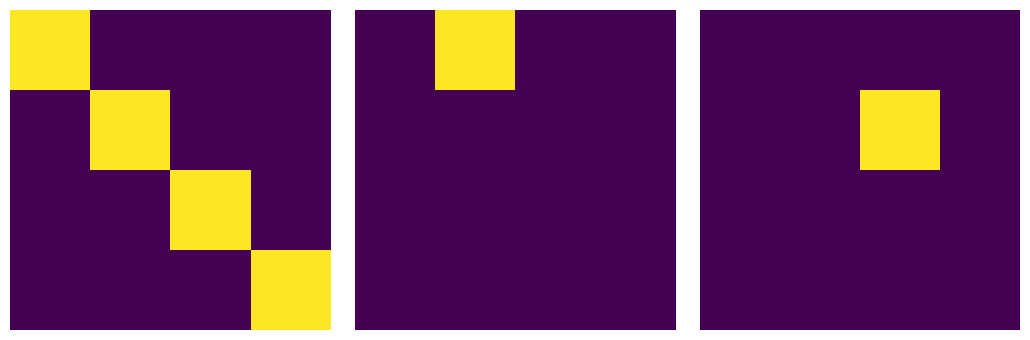

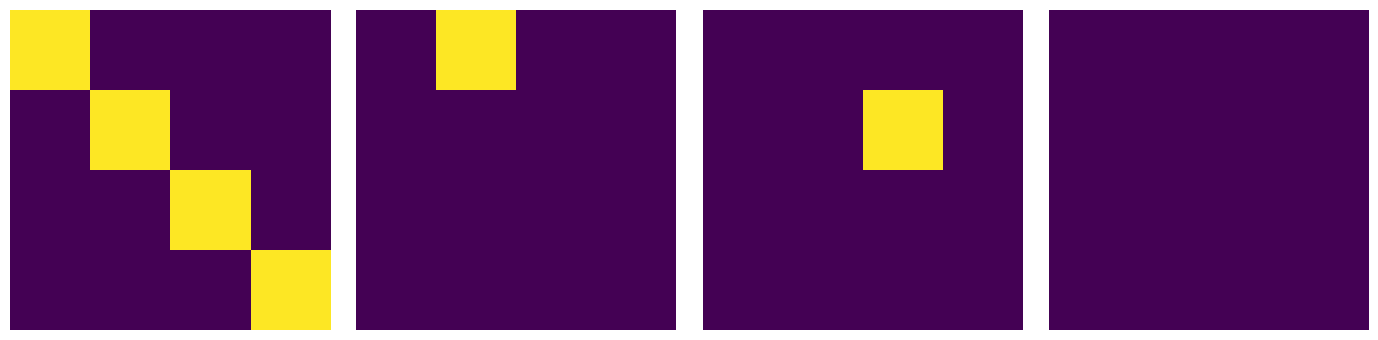

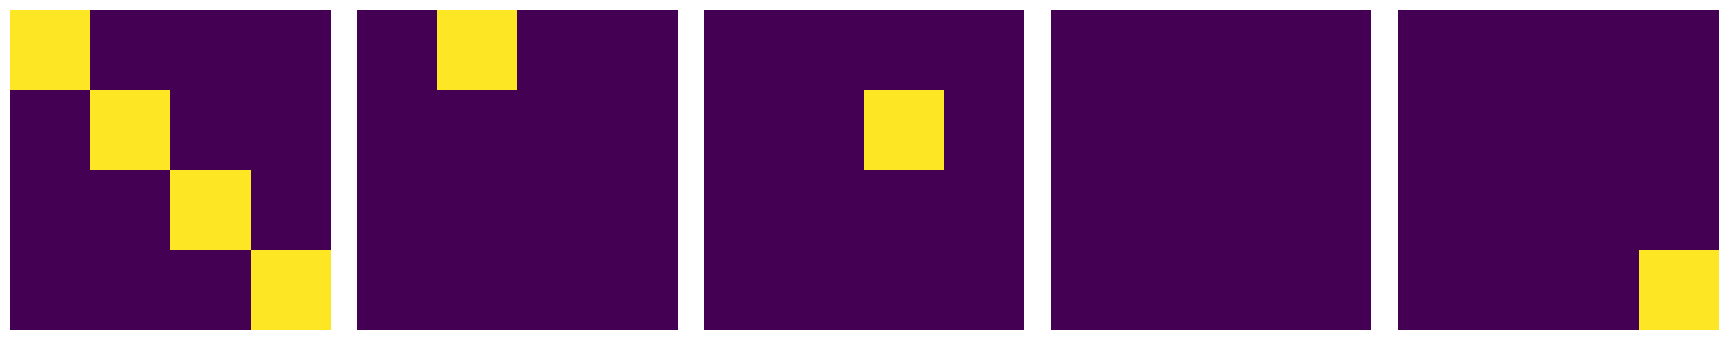

In [7]:
%%time
metrics = np.zeros((3,4))
infs = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
    gcstar.fit(X, verbose = 1)
    
    infs.append(gcstar.get_connectivity_matrix(simulation=False))
    gcstar.plot_extended_connectivity_matrix()
    gcstar.compute_confusion_matrix(A, simulation = False)
    metrics[i] =  gcstar.compute_metrics()

In [8]:
metrics

array([[1., 1., 1., 0.],
       [1., 1., 1., 0.],
       [1., 1., 1., 0.]])

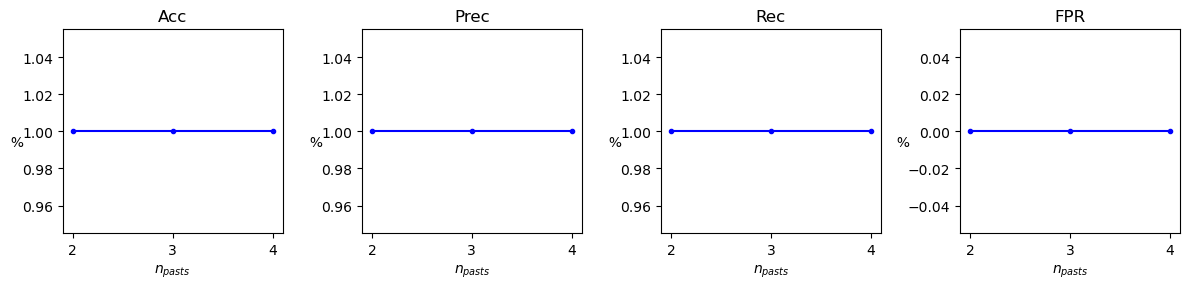

In [9]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(2, 5, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

In [10]:
def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)

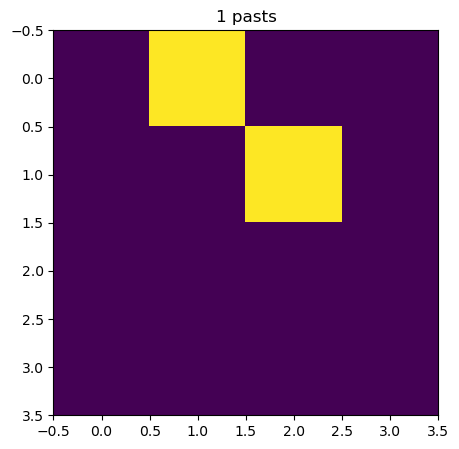

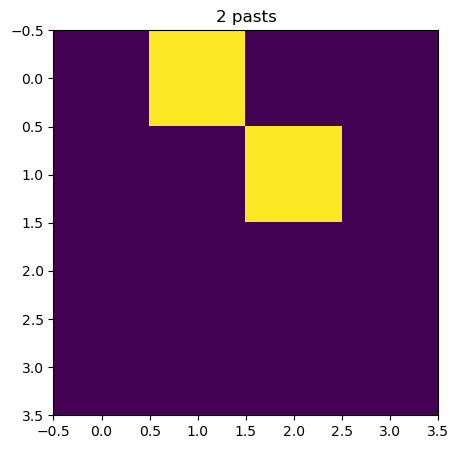

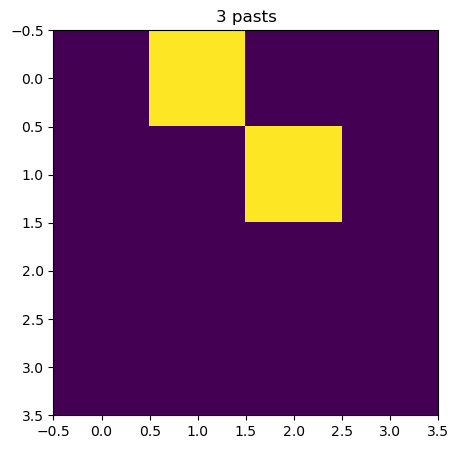

In [11]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(A, el))
    plt.title(f'{i+1} pasts')